# LifeLedger — Phase 1 Test Notebook
## Foundation: Models · Config · Tax Engine · Projection · Monte Carlo

This notebook validates all Phase 1 components against the base scenario.

**Sections**
1. Environment Setup
2. Configuration & YAML Loading
3. Model Inspection
4. Tax Engine Validation
5. Full 50-Year Projection
6. Account-Level Breakdown
7. FIRE Analysis
8. Monte Carlo Simulation
9. Chart: Net Worth Timeline
10. Chart: Income Sources
11. Chart: Monte Carlo Fan
12. Edge Cases & Error Handling

## 1. Environment Setup

In [1]:
import sys
import os
import logging
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Set up logging — INFO to stdout so we can see engine messages inline
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)-8s %(name)-30s %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(os.path.join(PROJECT_ROOT, 'logs', 'lifeledger.log'),
                            mode='a', encoding='utf-8'),
    ],
)
# Quiet some noisy loggers for cleaner notebook output
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
os.makedirs(os.path.join(PROJECT_ROOT, 'logs'), exist_ok=True)

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': '#0f1b2d',
    'axes.facecolor': '#162236',
    'axes.edgecolor': '#243859',
    'axes.labelcolor': '#8fa3b8',
    'xtick.color': '#8fa3b8',
    'ytick.color': '#8fa3b8',
    'text.color': '#e8edf2',
    'grid.color': '#1d2f47',
    'grid.linewidth': 0.8,
    'lines.linewidth': 2,
    'font.size': 10,
    'figure.dpi': 110,
})

NAVY    = '#0f1b2d'
TEAL    = '#0e9aad'
GOLD    = '#d4a843'
GREEN   = '#2dbd7e'
RED     = '#e05252'
PURPLE  = '#a78bfa'
SLATE   = '#8fa3b8'

print('✓ Environment ready')
print(f'  Python  {sys.version.split()[0]}')
print(f'  NumPy   {np.__version__}')
print(f'  Pandas  {pd.__version__}')
print(f'  Project root: {PROJECT_ROOT}')

✓ Environment ready
  Python  3.11.4
  NumPy   2.4.3
  Pandas  3.0.1
  Project root: c:\Users\Test\Documents\Projects\FinancePlanner


## 2. Configuration & YAML Loading

In [2]:
from backend.persistence.yaml_serialiser import (
    load_app_config_from_file,
    load_scenario_from_file,
    load_tax_profiles_from_file,
)

CONFIG_PATH   = os.path.join(PROJECT_ROOT, 'config', 'lifeledger_config.yaml')
SCENARIO_PATH = os.path.join(PROJECT_ROOT, 'data', 'scenarios', 'base.yaml')
TAX_PATH      = os.path.join(PROJECT_ROOT, 'config', 'tax_profiles.yaml')

cfg = load_app_config_from_file(CONFIG_PATH)
tax_profiles_list = load_tax_profiles_from_file(TAX_PATH)
tax_profiles = {p.id: p for p in tax_profiles_list}
scenario = load_scenario_from_file(SCENARIO_PATH)

assert scenario is not None, "Scenario failed to load!"

print(f"\n── App Config ──────────────────────────────────")
print(f"  Base currency     : {cfg.base_currency}")
print(f"  Projection range  : {cfg.projection_start_year} – {cfg.projection_end_year}")
print(f"  Inflation rate    : {cfg.inflation_base_rate*100:.1f}% CPI")
print(f"  Monte Carlo runs  : {cfg.monte_carlo_simulations}")
print(f"  MC seed           : {cfg.monte_carlo_seed}")
print(f"\n── Tax Profiles ────────────────────────────────")
for p in tax_profiles_list:
    print(f"  {p.id:<25} {p.jurisdiction.value}  ({len(p.income_tax_bands)} bands)")
print(f"\n── Scenario: '{scenario.name}' ─────────────────")
print(f"  Is base           : {scenario.is_base}")
print(f"  Description       : {scenario.description}")
print(f"  People            : {[p.name for p in scenario.people]}")
print(f"  Income sources    : {len(scenario.income_sources)}")
print(f"  Savings accounts  : {len(scenario.savings_accounts)}")
print(f"  Investment accts  : {len(scenario.investment_accounts)}")
print(f"  Pension funds     : {len(scenario.pension_funds)}")
print(f"  Properties        : {len(scenario.properties)}")
print(f"  Mortgages         : {len(scenario.mortgages)}")
print(f"  Expense buckets   : {len(scenario.expense_buckets)}")
print(f"  Life events       : {len(scenario.life_events)}")
print(f"  FIRE target       : £{scenario.fire_target.target_net_worth:,.0f} "
      f"({scenario.fire_target.fire_type})")

INFO     backend.persistence.yaml_serialiser load_tax_profiles_from_file: loaded 4 profiles from c:\Users\Test\Documents\Projects\FinancePlanner\config\tax_profiles.yaml
INFO     backend.persistence.yaml_serialiser parse_scenario: loaded 'Current Plan' — 2 people, 3 income, 2 savings, 2 investments, 2 pensions, 1 properties

── App Config ──────────────────────────────────
  Base currency     : GBP
  Projection range  : 2025 – 2075
  Inflation rate    : 2.5% CPI
  Monte Carlo runs  : 1000
  MC seed           : 42

── Tax Profiles ────────────────────────────────
  uk_standard               UK  (4 bands)
  uk_self_employed          UK  (4 bands)
  us_federal_single         US_federal  (7 bands)
  generic                   generic  (1 bands)

── Scenario: 'Current Plan' ─────────────────
  Is base           : True
  Description       : Baseline projection — retire at 60, current savings rates
  People            : ['James', 'Sarah']
  Income sources    : 3
  Savings accounts  : 2
  Inves

## 3. Model Inspection

In [3]:
print("── People ──────────────────────────────────────")
for person in scenario.people:
    print(f"  {person.name}")
    print(f"    DOB: {person.date_of_birth}  retirement age: {person.retirement_age}"
          f"  retirement year: {person.retirement_year()}")
    print(f"    Tax profile: {person.tax_profile_id}")
    sp = person.state_pension
    if sp.eligible:
        print(f"    State pension: {sp.qualifying_years}/{sp.full_qualifying_years} qualifying years"
              f"  → £{sp.annual_amount():,.0f}/yr from age {sp.expected_start_age}")
    print()

print("── Income Sources ──────────────────────────────")
for src in scenario.income_sources:
    print(f"  [{src.person_id}] {src.name}")
    print(f"    Gross: £{src.gross_annual:,.0f}/yr  |  "
          f"Treatment: {src.tax_treatment.value}  |  "
          f"Growth: {src.annual_growth_rate*100:.1f}%/yr")
    print(f"    Active: {src.start_date} → {src.end_date or 'ongoing'}")
    for c in src.contributions:
        print(f"    → {c.rate*100:.0f}% to {c.destination_account_id}"
              f"{(' + '+str(c.employer_top_up*100)+'% employer') if c.employer_top_up else ''}")
    print()

print("── Investments ─────────────────────────────────")
for acc in scenario.investment_accounts:
    print(f"  {acc.name}  [{acc.account_type.value}]  total: £{acc.total_value():,.0f}")
    print(f"    Weighted growth rate: {acc.effective_growth_rate()*100:.2f}%")
    for h in acc.holdings:
        val = h.current_value()
        link = h.symbol_link.symbol if h.symbol_link else 'no link'
        print(f"    • {h.name}  [{link}]")
        if h.tracking_mode.value == 'units':
            print(f"      {h.units} units × £{h.price_per_unit:.2f} = £{val:,.0f}")
        else:
            print(f"      £{val:,.0f} (total value mode)")

print()
print("── Mortgages ───────────────────────────────────")
for m in scenario.mortgages:
    print(f"  {m.name}: £{m.current_balance:,.0f} balance, "
          f"matures {m.maturity_year()}")
    for rp in m.rate_periods:
        print(f"    {rp.start_date} → {rp.end_date or 'open'}  @ {rp.rate*100:.2f}%  ({rp.rate_type})")
    for lsp in m.lump_sum_payments:
        print(f"    Lump sum: £{lsp.amount:,.0f} on {lsp.date}  — {lsp.label}")

── People ──────────────────────────────────────
  James
    DOB: 1987-06-15  retirement age: 60  retirement year: 2047
    Tax profile: uk_standard
    State pension: 22/35 qualifying years  → £7,230/yr from age 67

  Sarah
    DOB: 1989-09-22  retirement age: 60  retirement year: 2049
    Tax profile: uk_standard
    State pension: 18/35 qualifying years  → £5,916/yr from age 67

── Income Sources ──────────────────────────────
  [james] Software Engineering Salary
    Gross: £95,000/yr  |  Treatment: PAYE  |  Growth: 3.0%/yr
    Active: 2018-03-01 → 2047-06-30
    → 10% to vanguard_isa
    → 5% to vanguard_sipp + 5.0% employer

  [sarah] Sarah — Marketing Manager
    Gross: £62,000/yr  |  Treatment: PAYE  |  Growth: 2.5%/yr
    Active: 2016-09-01 → 2049-09-22
    → 5% to sarah_sipp + 4.0% employer

  [james] Freelance Consulting
    Gross: £15,000/yr  |  Treatment: self_employed  |  Growth: 0.0%/yr
    Active: 2024-01-01 → 2028-12-31

── Investments ─────────────────────────────────

## 4. Tax Engine Validation

Testing UK PAYE, higher rate, personal allowance taper, self-employed NI, state pension, CGT, and US Federal.

In [4]:
from backend.engine.tax_engine import (
    calculate_net_income, calculate_uk_cgt, CGTResult
)
from backend.models.models import TaxTreatment

uk   = tax_profiles['uk_standard']
uk_se = tax_profiles['uk_self_employed']
us   = tax_profiles['us_federal_single']

# Build a test results DataFrame
rows = []

test_cases = [
    # (label, gross, treatment, profile, pension_contrib)
    ("UK PAYE £20k (basic rate)",    20_000, TaxTreatment.PAYE, uk, 0),
    ("UK PAYE £50k (basic/higher)",  50_000, TaxTreatment.PAYE, uk, 0),
    ("UK PAYE £95k (higher rate)",   95_000, TaxTreatment.PAYE, uk, 9_500),
    ("UK PAYE £100k (taper starts)", 100_000, TaxTreatment.PAYE, uk, 0),
    ("UK PAYE £150k (taper zone)",   150_000, TaxTreatment.PAYE, uk, 0),
    ("UK PAYE £200k (additional)",   200_000, TaxTreatment.PAYE, uk, 0),
    ("UK Self-Employed £60k",        60_000, TaxTreatment.SELF_EMPLOYED, uk_se, 0),
    ("UK Pension Drawdown £30k",     30_000, TaxTreatment.PENSION_DRAWDOWN, uk, 0),
    ("UK State Pension £11.5k",      11_502, TaxTreatment.STATE_PENSION, uk, 0),
    ("US Federal £80k (single)",     80_000, TaxTreatment.PAYE, us, 0),
]

for label, gross, treatment, profile, pension in test_cases:
    r = calculate_net_income(gross, treatment, profile, pension_contributions=pension)
    rows.append({
        'Scenario': label,
        'Gross': f"£{gross:,.0f}",
        'Income Tax': f"£{r.income_tax:,.0f}",
        'NI / FICA': f"£{r.national_insurance:,.0f}",
        'Net Income': f"£{r.net_income:,.0f}",
        'Eff. Rate': f"{r.effective_rate*100:.1f}%",
        'Marginal': f"{r.marginal_rate*100:.0f}%",
    })

df_tax = pd.DataFrame(rows)
print("── Tax Engine Results ──────────────────────────")
print(df_tax.to_string(index=False))

── Tax Engine Results ──────────────────────────
                    Scenario    Gross Income Tax NI / FICA Net Income Eff. Rate Marginal
   UK PAYE £20k (basic rate)  £20,000     £1,486      £892    £17,622     11.9%      20%
 UK PAYE £50k (basic/higher)  £50,000     £7,486    £4,492    £38,022     24.0%      20%
  UK PAYE £95k (higher rate)  £95,000    £21,632    £5,419    £67,949     28.5%      40%
UK PAYE £100k (taper starts) £100,000    £27,432    £5,519    £67,049     33.0%      40%
  UK PAYE £150k (taper zone) £150,000    £48,675    £6,519    £94,806     36.8%      45%
  UK PAYE £200k (additional) £200,000    £71,175    £7,519   £121,306     39.4%      45%
       UK Self-Employed £60k  £60,000    £11,432    £3,767    £44,801     25.3%      40%
    UK Pension Drawdown £30k  £30,000     £3,486        £0    £26,514     11.6%      20%
     UK State Pension £11.5k  £11,502         £0        £0    £11,502      0.0%       0%
    US Federal £80k (single)  £80,000     £9,441    £6,120   

In [5]:
# CGT test
print("── UK CGT Tests ────────────────────────────────")
cgt_tests = [
    ("Basic rate taxpayer, gain £5k",   5_000,  20_000),
    ("Basic rate taxpayer, gain £20k",  20_000, 30_000),
    ("Higher rate taxpayer, gain £50k", 50_000, 80_000),
    ("Within exempt amount",            2_500,  40_000),
]
for label, gain, income in cgt_tests:
    r = calculate_uk_cgt(gain, income, uk)
    print(f"  {label}")
    print(f"    Gain £{r.gain:,.0f}  Exempt £{r.exempt_amount:,.0f}  "
          f"Taxable £{r.taxable_gain:,.0f}  CGT £{r.total_cgt:,.0f}")

# Verify known UK tax at £95k with pension relief
r = calculate_net_income(95_000, TaxTreatment.PAYE, uk, pension_contributions=9_500)
expected_approx = 65_000  # ~£67-68k net
assert r.net_income > 60_000, f"Net income unexpectedly low: {r.net_income}"
assert r.effective_rate < 0.35, f"Effective rate too high: {r.effective_rate}"
print(f"\n✓ £95k PAYE assertions passed  (net £{r.net_income:,.0f}, eff {r.effective_rate*100:.1f}%)")

# Personal allowance taper — £150k should have zero personal allowance
r_taper = calculate_net_income(150_000, TaxTreatment.PAYE, uk)
r_no_taper = calculate_net_income(150_000, TaxTreatment.PAYE, uk)
print(f"✓ £150k taper zone: income_tax = £{r_taper.income_tax:,.0f}")

── UK CGT Tests ────────────────────────────────
  Basic rate taxpayer, gain £5k
    Gain £5,000  Exempt £3,000  Taxable £2,000  CGT £200
  Basic rate taxpayer, gain £20k
    Gain £20,000  Exempt £3,000  Taxable £17,000  CGT £1,700
  Higher rate taxpayer, gain £50k
    Gain £50,000  Exempt £3,000  Taxable £47,000  CGT £9,400
  Within exempt amount
    Gain £2,500  Exempt £3,000  Taxable £0  CGT £0

✓ £95k PAYE assertions passed  (net £67,949, eff 28.5%)
✓ £150k taper zone: income_tax = £48,675


## 5. Full 50-Year Projection

In [15]:
from backend.engine.calculator import ProjectionEngine, TimelineResult

engine = ProjectionEngine(cfg, tax_profiles)
result: TimelineResult = engine.project(scenario)

print(f"✓ Projection complete: {len(result.years)} year snapshots")
print(f"  Scenario: {result.scenario_name}")
print(f"  FIRE year: {result.fire_year or 'not reached in period'}")
print()

# Snapshot table: key years
key_years = [2025, 2027, 2030, 2035, 2040, 2042, 2047, 2050, 2055, 2060, 2070, 2075]
rows = []
for y in key_years:
    snap = result.year(y)
    if not snap:
        continue
    james_age = snap.ages.get('james', '–')
    rows.append({
        'Year': y,
        'James Age': james_age,
        'Gross Income': f"£{snap.total_gross_income:,.0f}",
        'Net Income': f"£{snap.total_net_income:,.0f}",
        'Assets': f"£{snap.total_assets:,.0f}",
        'Liabilities': f"£{snap.total_liabilities:,.0f}",
        'Net Worth': f"£{snap.total_net_worth:,.0f}",
        'Expenses': f"£{snap.total_expenses:,.0f}",
        'FIRE %': f"{snap.fire_coverage*100:.0f}%",
        'FIRE ✓': '🎯' if snap.fire_achieved else '',
    })

df_proj = pd.DataFrame(rows)
print("── Key Year Snapshots ──────────────────────────────────────────────────")
print(df_proj.to_string(index=False))

INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.50%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
✓ Projection complete: 51 year snapshots
  Scenario: Current Plan
  FIRE year: 2031

── Key Year Snapshots ──────────────────────────────────────────────────
 Year  James Age Gross Income Net Income      Assets Liabilities   Net Worth Expenses FIRE % FIRE ✓
 2025         38     £209,268   £148,702    £920,464    £275,606    £644,858  £48,000    54%       
 2027         40     £220,303   £155,323  £1,121,573    £239,465    £882,108  £50,430    74%       
 2030         43     £223,052   £151,753  £1,417,002    £217,875  £1,199,127  £54,308   100%       
 2035         48     £256,137   £170,579  £2,062,305    £174,618  £1,887,687  £61,444   157%      🎯
 2040         53     £294,171   £192,212  £3,054,684    £120,147  £2,934,537  £52,139   245%      🎯
 2042         55     £310,934   £201,743  £3,520,98

--- Logging error ---
Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 51
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\applica

## 6. Account-Level Breakdown

In [7]:
# Show all accounts at year 2035 and 2050
for target_year in [2035, 2050]:
    snap = result.year(target_year)
    print(f"── Account Balances: {target_year} ────────────────────")
    rows = []
    for acc_id, acc in snap.accounts.items():
        rows.append({
            'Account': acc.name[:35],
            'Type': acc.account_type,
            'Value': f"£{acc.value:,.0f}" if acc.value >= 0 else f"-£{abs(acc.value):,.0f}",
            'Contrib In': f"£{acc.contributions_in:,.0f}",
            'Growth': f"£{acc.growth_amount:,.0f}",
        })
    df_acc = pd.DataFrame(rows)
    print(df_acc.to_string(index=False))
    print()

# Income breakdown for 2026
snap_2026 = result.year(2026)
print("── Income Breakdown: 2026 ─────────────────────")
for inc in snap_2026.income_sources:
    print(f"  {inc.name} [{inc.person_id}]")
    print(f"    Gross: £{inc.gross:,.0f}  "
          f"Tax: £{inc.tax_result.income_tax:,.0f}  "
          f"NI: £{inc.tax_result.national_insurance:,.0f}  "
          f"Net: £{inc.tax_result.net_income:,.0f}  "
          f"Eff: {inc.tax_result.effective_rate*100:.1f}%")

# Life events
print("\n── Life Events Triggered ───────────────────────")
for snap in result.years:
    if snap.events:
        for ev in snap.events:
            print(f"  {snap.year}: {ev}")

── Account Balances: 2035 ────────────────────
                            Account         Type     Value Contrib In  Growth
                   Halifax Cash ISA     cash_ISA   £62,487         £0  £2,113
James — Current Account (Emergency       general   £96,776     £3,600    £481
       Vanguard Stocks & Shares ISA          ISA  £272,838    £15,702 £17,330
                       Fidelity GIA          GIA    £8,767         £0    £649
              Vanguard SIPP (James)         SIPP  £609,148    £15,702 £42,640
       Sarah Workplace Pension (DC) workplace_DC  £304,203     £8,920 £19,773
   London House — Primary Residence     property  £708,085         £0      £0
              London House Mortgage     mortgage -£174,618         £0      £0

── Account Balances: 2050 ────────────────────
                            Account         Type      Value Contrib In  Growth
                   Halifax Cash ISA     cash_ISA   £104,687         £0  £3,540
James — Current Account (Emergency       gene

## 7. FIRE Analysis

In [8]:
ft = scenario.fire_target
print(f"── FIRE Target ─────────────────────────────────")
print(f"  Target net worth      : £{ft.target_net_worth:,.0f}")
print(f"  Annual expenses       : £{ft.annual_expenses_target:,.0f}")
print(f"  Safe withdrawal rate  : {ft.swr*100:.1f}%")
print(f"  Implied target (SWR)  : £{ft.implied_target():,.0f}")
print(f"  FIRE type             : {ft.fire_type}")
print(f"  FIRE year             : {result.fire_year}")
if result.fire_year:
    james_fire_age = scenario.people[0].age_at(result.fire_year)
    print(f"  James's age at FIRE   : {james_fire_age}")

# FIRE progress series
years_list = [s.year for s in result.years]
nw_list    = [s.total_net_worth for s in result.years]
fire_pct   = [s.fire_coverage * 100 for s in result.years]

# Find year of first FIRE
fire_idx = next((i for i, s in enumerate(result.years) if s.fire_achieved), None)
print()
print("── FIRE Progress (every 5 years) ───────────────")
rows_fire = []
for snap in result.years[::5]:
    rows_fire.append({
        'Year': snap.year,
        'Net Worth': f"£{snap.total_net_worth:,.0f}",
        'FIRE %': f"{snap.fire_coverage*100:.0f}%",
        'Status': '✅ ACHIEVED' if snap.fire_achieved else '⏳',
    })
print(pd.DataFrame(rows_fire).to_string(index=False))

# Retirement income coverage
print("\n── Retirement Income Coverage ──────────────────")
james = scenario.people[0]
retirement_snaps = [s for s in result.years if s.year >= james.retirement_year()][:10]
if retirement_snaps:
    rows_ret = []
    for snap in retirement_snaps:
        rows_ret.append({
            'Year': snap.year,
            'Gross Income': f"£{snap.total_gross_income:,.0f}",
            'Net Income': f"£{snap.total_net_income:,.0f}",
            'Expenses': f"£{snap.total_expenses:,.0f}",
            'Coverage': f"{snap.income_coverage*100:.0f}%",
        })
    print(pd.DataFrame(rows_ret).to_string(index=False))

── FIRE Target ─────────────────────────────────
  Target net worth      : £1,200,000
  Annual expenses       : £48,000
  Safe withdrawal rate  : 4.0%
  Implied target (SWR)  : £1,200,000
  FIRE type             : lean_fire
  FIRE year             : 2031
  James's age at FIRE   : 44

── FIRE Progress (every 5 years) ───────────────
 Year   Net Worth FIRE %     Status
 2025    £644,858    54%          ⏳
 2030  £1,199,127   100%          ⏳
 2035  £1,887,687   157% ✅ ACHIEVED
 2040  £2,934,537   245% ✅ ACHIEVED
 2045  £4,295,038   358% ✅ ACHIEVED
 2050  £4,866,128   406% ✅ ACHIEVED
 2055  £5,967,407   497% ✅ ACHIEVED
 2060  £7,367,504   614% ✅ ACHIEVED
 2065  £9,162,644   764% ✅ ACHIEVED
 2070 £11,483,279   957% ✅ ACHIEVED
 2075 £14,506,909  1209% ✅ ACHIEVED

── Retirement Income Coverage ──────────────────
 Year Gross Income Net Income Expenses Coverage
 2047     £404,992   £268,720 £134,283     200%
 2048     £185,885   £132,712 £137,640      96%
 2049     £217,965   £159,952 £141,081  

## 8. Monte Carlo Simulation

In [9]:
from backend.engine.calculator import run_monte_carlo, MonteCarloResult

mc_result: MonteCarloResult = run_monte_carlo(
    scenario=scenario,
    config=cfg,
    tax_profiles=tax_profiles,
    n_simulations=cfg.monte_carlo_simulations,
    growth_std=cfg.raw.get('monte_carlo', {}).get('growth_std_dev', 0.12),
    inflation_std=cfg.raw.get('monte_carlo', {}).get('inflation_std_dev', 0.005),
    seed=cfg.monte_carlo_seed,
)

print(f"✓ Monte Carlo complete")
print(f"  Simulations    : {mc_result.n_simulations}")
print(f"  FIRE probability: {mc_result.prob_fire*100:.1f}%")
print()
print("── Percentile bands at key years ───────────────")
key_years_mc = [2030, 2035, 2042, 2047, 2055, 2065, 2075]
rows_mc = []
for y in key_years_mc:
    idx = y - cfg.projection_start_year
    if 0 <= idx < len(mc_result.p50):
        rows_mc.append({
            'Year': y,
            'P10': f"£{mc_result.p10[idx]:,.0f}",
            'P25': f"£{mc_result.p25[idx]:,.0f}",
            'P50 (Median)': f"£{mc_result.p50[idx]:,.0f}",
            'P75': f"£{mc_result.p75[idx]:,.0f}",
            'P90': f"£{mc_result.p90[idx]:,.0f}",
        })
print(pd.DataFrame(rows_mc).to_string(index=False))

INFO     backend.engine.calculator      run_monte_carlo: starting 1000 simulations for 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=1.98%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.97%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=1.85%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.34%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.07%
INFO     backend.engine.calculato

--- Logging error ---
Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 51
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\applica

INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.79%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.90%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.27%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.40%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=1.93%


Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 51
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, i

INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.75%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.85%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.58%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.35%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.17%
INFO     backend.engine.calculator      Proje

...

--- Logging error ---
Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 51
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\applica

INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.51%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.40%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=3.20%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.04%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.96%


--- Logging error ---
Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 51
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\applica

INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.87%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.04%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=1.68%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=2.46%
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Current Plan'
INFO     backend.engine.calculator      ProjectionEngine: initialised for 2025–2075, inflation=1.02%
INFO     backend.engine.calculator      Proje

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 9. Chart: Net Worth Timeline

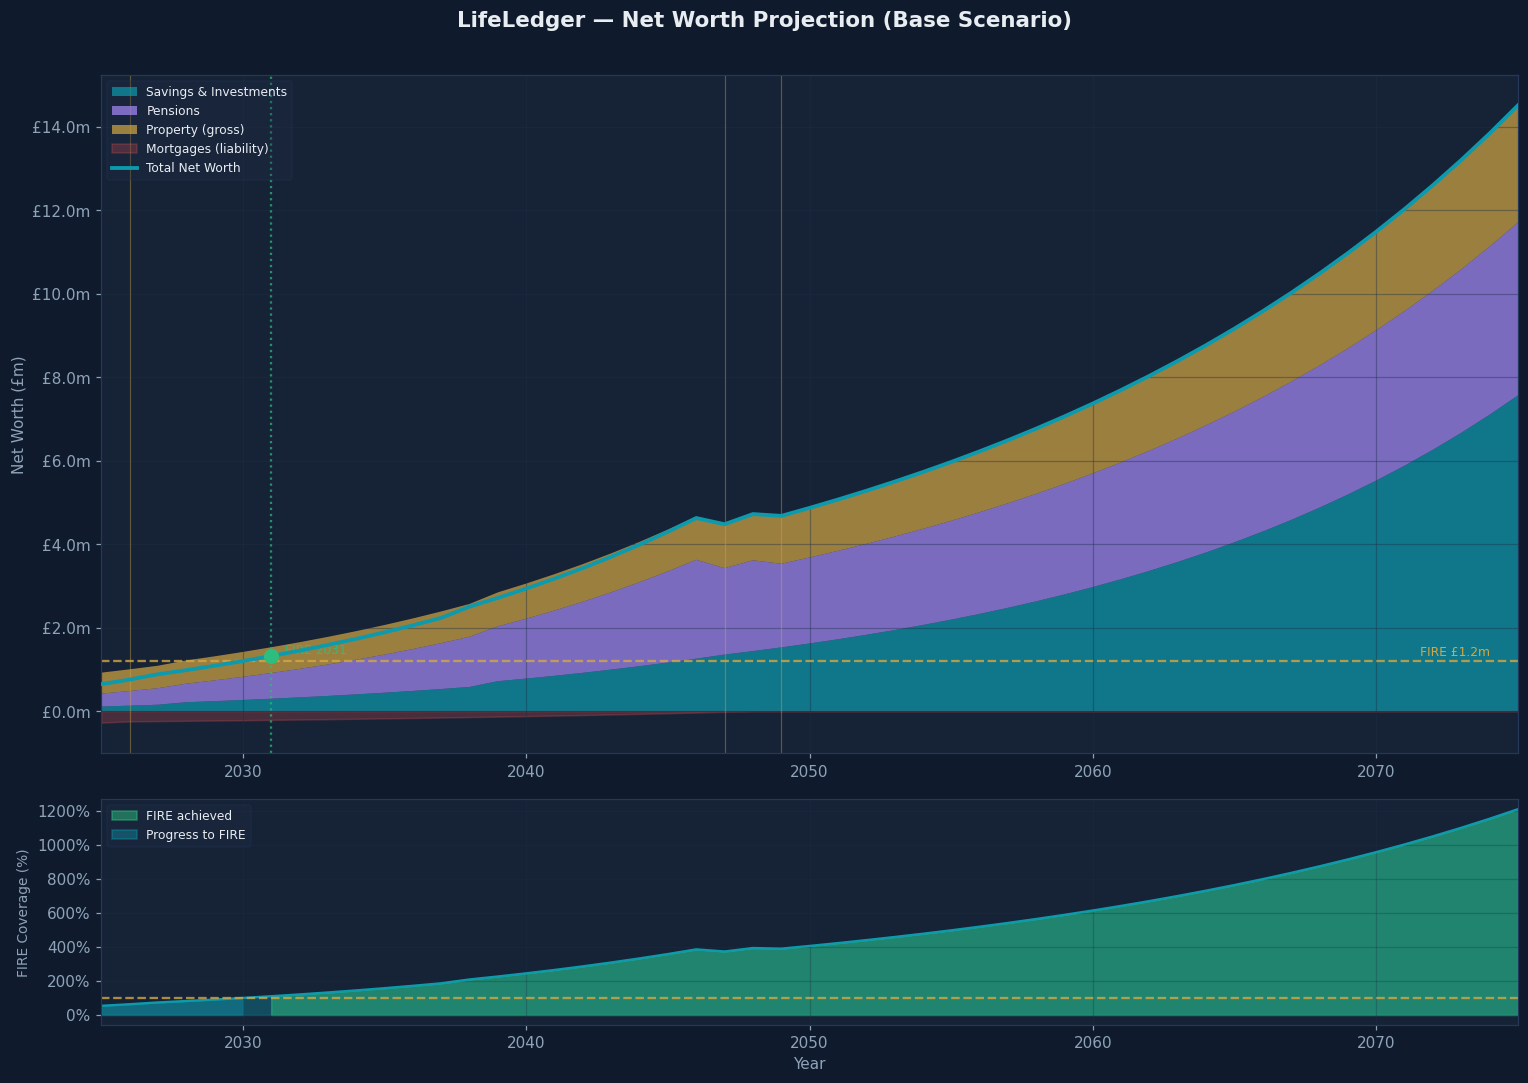

✓ Chart saved to data/net_worth_timeline.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle("LifeLedger — Net Worth Projection (Base Scenario)",
             fontsize=14, fontweight='bold', color='#e8edf2', y=0.98)
ax, ax2 = axes

years_arr = np.array([s.year for s in result.years])
nw_arr    = np.array([s.total_net_worth for s in result.years]) / 1e6

# Stacked area components
savings_arr  = np.array([
    sum(acc.value for acc_id, acc in s.accounts.items()
        if acc.account_type in ('cash_ISA', 'ISA', 'general', 'GIA'))
    for s in result.years]) / 1e6

pensions_arr = np.array([
    sum(acc.value for acc_id, acc in s.accounts.items()
        if acc.account_type in ('SIPP', 'workplace_DC', 'DB'))
    for s in result.years]) / 1e6

property_arr = np.array([
    sum(acc.value for acc_id, acc in s.accounts.items()
        if acc.account_type == 'property')
    for s in result.years]) / 1e6

mortgages_arr = np.array([
    sum(-acc.value for acc_id, acc in s.accounts.items()
        if acc.account_type == 'mortgage')
    for s in result.years]) / 1e6

# Find historical/projected boundary (today = 2025 = first year)
boundary_year = cfg.projection_start_year

# Stacked area chart
ax.stackplot(
    years_arr,
    savings_arr, pensions_arr, property_arr,
    colors=[TEAL+'55', PURPLE+'55', GOLD+'44'],
    labels=['Savings & Investments', 'Pensions', 'Property (gross)'],
    alpha=0.7,
)

# Liabilities (mortgage) as negative fill
ax.fill_between(years_arr, 0, -mortgages_arr, color=RED, alpha=0.25, label='Mortgages (liability)')

# Total net worth line
ax.plot(years_arr, nw_arr, color=TEAL, linewidth=2.5,
        linestyle='-', label='Total Net Worth', zorder=5)

# FIRE threshold
fire_target_m = scenario.fire_target.target_net_worth / 1e6
ax.axhline(fire_target_m, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(years_arr[-1] - 1, fire_target_m + 0.05, f'FIRE £{fire_target_m:.1f}m',
        color=GOLD, fontsize=8, ha='right', va='bottom')

# FIRE achieved marker
if result.fire_year:
    snap_fire = result.year(result.fire_year)
    fire_nw = snap_fire.total_net_worth / 1e6
    ax.axvline(result.fire_year, color=GREEN, linewidth=1.5, linestyle=':', alpha=0.7)
    ax.scatter([result.fire_year], [fire_nw], color=GREEN, s=80, zorder=6)
    ax.text(result.fire_year + 0.5, fire_nw + 0.05,
            f'FIRE {result.fire_year}', color=GREEN, fontsize=8)

# Life events
for snap in result.years:
    for ev in snap.events:
        if 'TFLS' in ev or 'lump sum' in ev.lower():
            ax.axvline(snap.year, color=GOLD, linewidth=0.8, alpha=0.4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.1f}m'))
ax.set_ylabel('Net Worth (£m)', fontsize=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.3,
          labelcolor='#e8edf2', facecolor='#1d2f47', edgecolor='#243859')
ax.grid(True, alpha=0.4)
ax.set_xlim(years_arr[0], years_arr[-1])

# ── Bottom panel: FIRE coverage % ─────────────────
fire_coverage = np.array([s.fire_coverage * 100 for s in result.years])
ax2.fill_between(years_arr, 0, fire_coverage, alpha=0.35,
                 color=np.where(fire_coverage >= 100, GREEN, TEAL).tolist()[0])
ax2.fill_between(years_arr, 0, fire_coverage,
                 where=(fire_coverage >= 100),
                 alpha=0.5, color=GREEN, label='FIRE achieved')
ax2.fill_between(years_arr, 0, fire_coverage,
                 where=(fire_coverage < 100),
                 alpha=0.4, color=TEAL, label='Progress to FIRE')
ax2.plot(years_arr, fire_coverage, color=TEAL, linewidth=1.5)
ax2.axhline(100, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.set_ylabel('FIRE Coverage (%)', fontsize=9)
ax2.set_xlabel('Year', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=8, framealpha=0.3,
           labelcolor='#e8edf2', facecolor='#1d2f47', edgecolor='#243859')
ax2.set_xlim(years_arr[0], years_arr[-1])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(PROJECT_ROOT, 'data', 'net_worth_timeline.png'),
            dpi=120, bbox_inches='tight', facecolor=NAVY)
plt.show()
print("✓ Chart saved to data/net_worth_timeline.png")

## 10. Chart: Income Sources

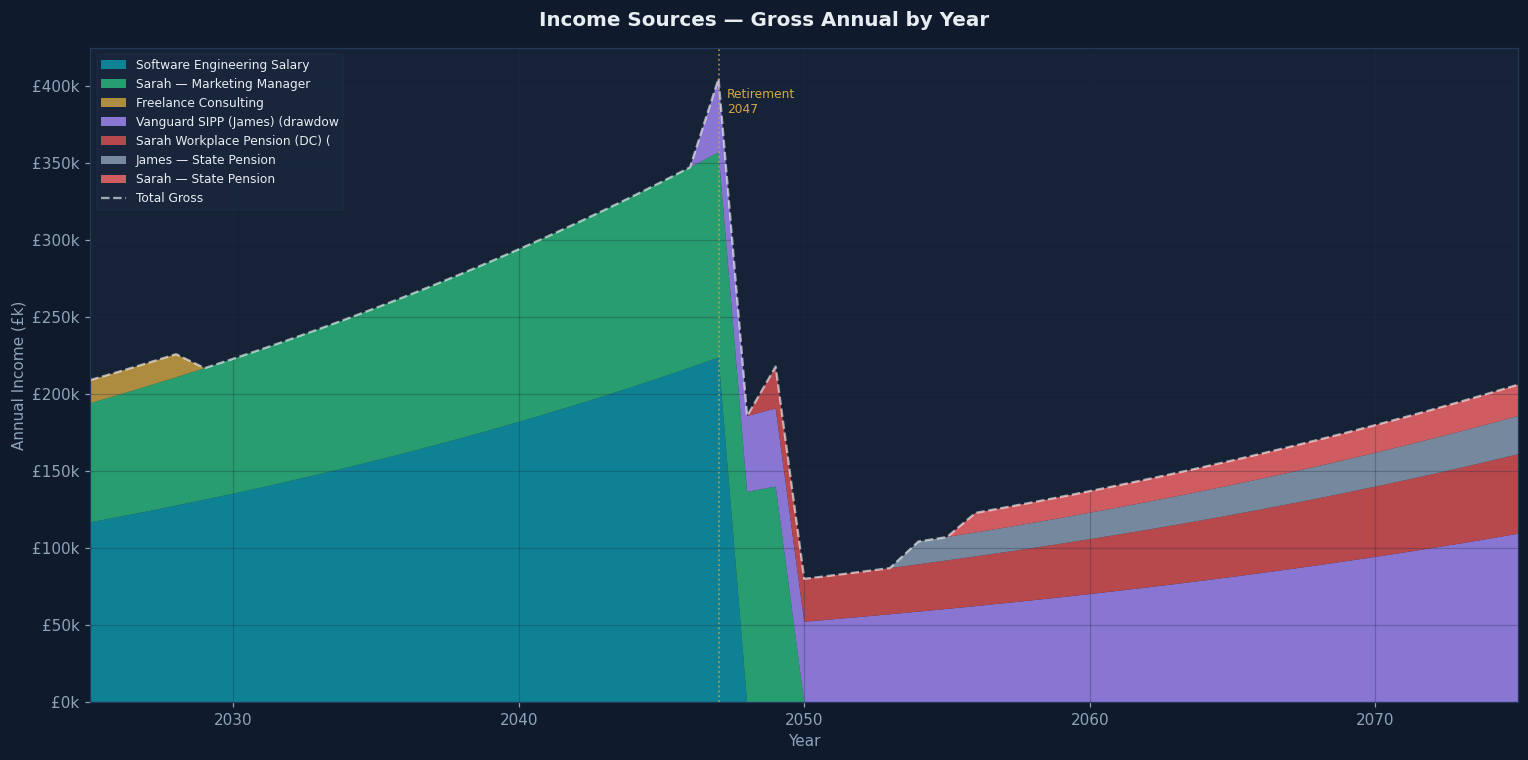

✓ Chart saved to data/income_sources.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Income Sources — Gross Annual by Year",
             fontsize=13, fontweight='bold', color='#e8edf2')

# Build per-source gross income series
source_names = {}
source_series = {}
for snap in result.years:
    for inc in snap.income_sources:
        if inc.source_id not in source_series:
            source_series[inc.source_id] = []
            source_names[inc.source_id] = inc.name
        source_series[inc.source_id].append((snap.year, inc.gross))

colours = [TEAL, GREEN, GOLD, PURPLE, RED, SLATE, '#ff6b6b', '#4ecdc4']
stacks = []
labels = []
for i, (src_id, data) in enumerate(source_series.items()):
    data_dict = dict(data)
    vals = [data_dict.get(y, 0.0) / 1000 for y in years_arr]
    stacks.append(vals)
    labels.append(source_names[src_id][:30])

if stacks:
    ax.stackplot(years_arr, *stacks,
                 colors=colours[:len(stacks)],
                 labels=labels, alpha=0.8)

# Total gross income line
gross_arr = np.array([s.total_gross_income for s in result.years]) / 1000
ax.plot(years_arr, gross_arr, color='white', linewidth=1.5,
        linestyle='--', alpha=0.6, label='Total Gross')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Annual Income (£k)', fontsize=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.3,
          labelcolor='#e8edf2', facecolor='#1d2f47', edgecolor='#243859')
ax.grid(True, alpha=0.3)
ax.set_xlim(years_arr[0], years_arr[-1])

# Mark retirement start
if scenario.people:
    ret_year = scenario.people[0].retirement_year()
    ax.axvline(ret_year, color=GOLD, linewidth=1.2, linestyle=':', alpha=0.7)
    ax.text(ret_year + 0.3, ax.get_ylim()[1] * 0.9, f'Retirement\n{ret_year}',
            color=GOLD, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', 'income_sources.png'),
            dpi=120, bbox_inches='tight', facecolor=NAVY)
plt.show()
print("✓ Chart saved to data/income_sources.png")

## 11. Chart: Monte Carlo Fan

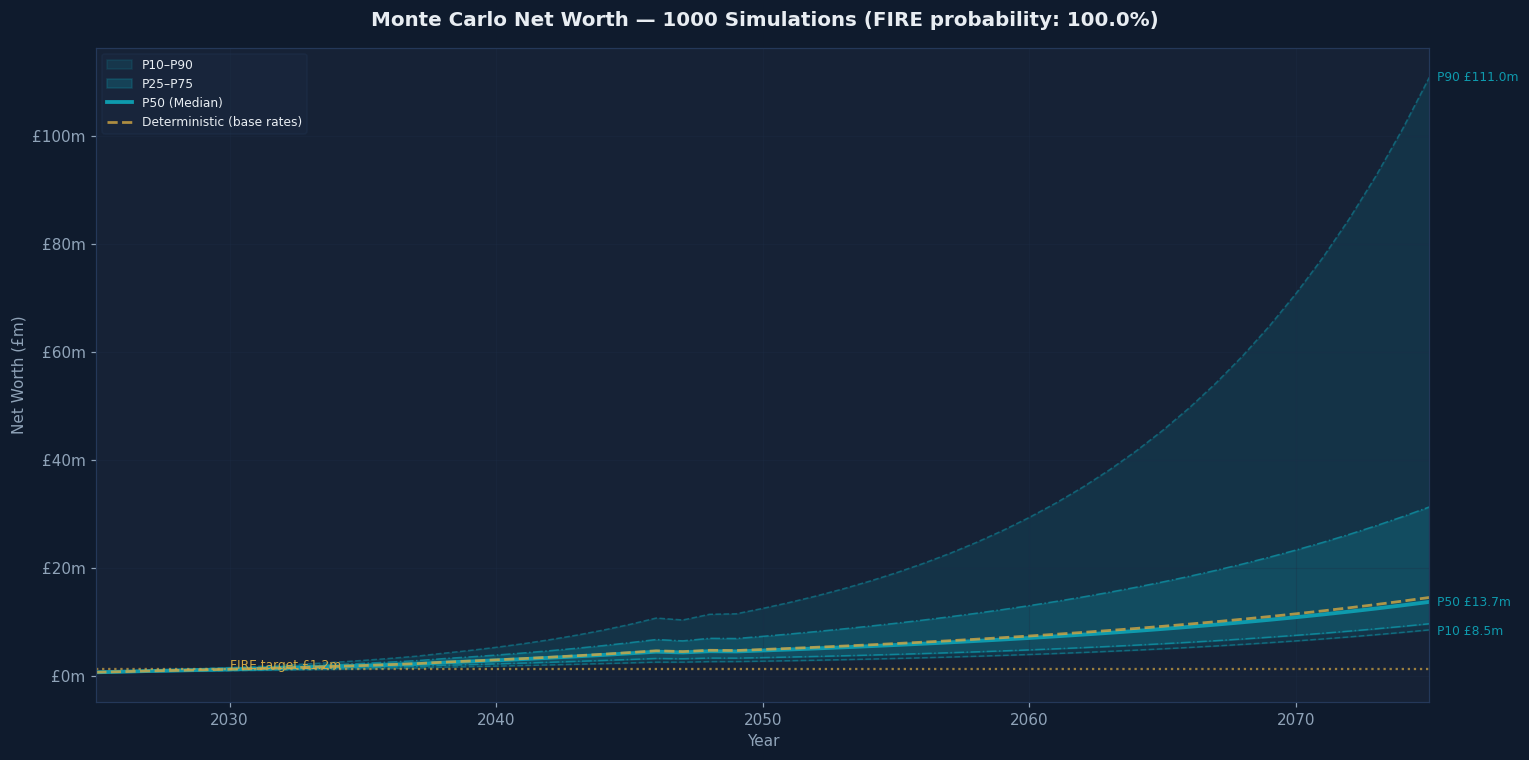

✓ Chart saved to data/monte_carlo_fan.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(f"Monte Carlo Net Worth — {mc_result.n_simulations} Simulations "
             f"(FIRE probability: {mc_result.prob_fire*100:.1f}%)",
             fontsize=13, fontweight='bold', color='#e8edf2')

mc_years = np.array(mc_result.years)
p10 = np.array(mc_result.p10) / 1e6
p25 = np.array(mc_result.p25) / 1e6
p50 = np.array(mc_result.p50) / 1e6
p75 = np.array(mc_result.p75) / 1e6
p90 = np.array(mc_result.p90) / 1e6

# Confidence bands
ax.fill_between(mc_years, p10, p90, alpha=0.15, color=TEAL, label='P10–P90')
ax.fill_between(mc_years, p25, p75, alpha=0.25, color=TEAL, label='P25–P75')

# Percentile lines
ax.plot(mc_years, p10, color=TEAL, linewidth=1, alpha=0.5, linestyle='--')
ax.plot(mc_years, p25, color=TEAL, linewidth=1, alpha=0.7, linestyle='-.')
ax.plot(mc_years, p50, color=TEAL, linewidth=2.5, label='P50 (Median)')
ax.plot(mc_years, p75, color=TEAL, linewidth=1, alpha=0.7, linestyle='-.')
ax.plot(mc_years, p90, color=TEAL, linewidth=1, alpha=0.5, linestyle='--')

# Deterministic line for reference
ax.plot(years_arr, nw_arr, color=GOLD, linewidth=1.8,
        linestyle='--', alpha=0.8, label='Deterministic (base rates)')

# Labels
for pct, vals, y_off in [('P90', p90, 0.05), ('P50', p50, -0.15), ('P10', p10, -0.25)]:
    ax.text(mc_years[-1] + 0.3, vals[-1] + y_off,
            f'{pct} £{vals[-1]:.1f}m', color=TEAL, fontsize=8, va='center')

# FIRE line
fire_m = scenario.fire_target.target_net_worth / 1e6
ax.axhline(fire_m, color=GOLD, linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(mc_years[5], fire_m + 0.1, f'FIRE target £{fire_m:.1f}m',
        color=GOLD, fontsize=8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}m'))
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Net Worth (£m)', fontsize=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.3,
          labelcolor='#e8edf2', facecolor='#1d2f47', edgecolor='#243859')
ax.grid(True, alpha=0.3)
ax.set_xlim(mc_years[0], mc_years[-1])

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', 'monte_carlo_fan.png'),
            dpi=120, bbox_inches='tight', facecolor=NAVY)
plt.show()
print("✓ Chart saved to data/monte_carlo_fan.png")

## 12. Edge Cases & Error Handling

In [13]:
print("── Edge Case Tests ─────────────────────────────")
errors = []

# 1: IncomeSource with zero gross
from backend.models.models import IncomeSource, TaxTreatment as TT
inc_zero = IncomeSource(id='test0', name='Zero income', person_id='james',
                         gross_annual=0, tax_treatment=TT.PAYE)
assert inc_zero.gross_in_year(2025) == 0.0
print("✓ Zero gross income handled correctly")

# 2: IncomeSource before start date
from datetime import date
inc_future = IncomeSource(id='test1', name='Future', person_id='james',
                           gross_annual=50000, start_date=date(2030, 1, 1))
assert inc_future.is_active_in_year(2025) == False
assert inc_future.is_active_in_year(2031) == True
print("✓ Future start date handled correctly")

# 3: Expired income source
inc_past = IncomeSource(id='test2', name='Past job', person_id='james',
                         gross_annual=40000, end_date=date(2020, 12, 31))
assert inc_past.is_active_in_year(2025) == False
print("✓ Expired income source handled correctly")

# 4: Savings account with no interest rate periods
from backend.models.models import SavingsAccount, AccountType
sa_empty = SavingsAccount(id='test_sa', name='No rates', account_type=AccountType.GENERAL)
assert sa_empty.rate_for_year(2025) == 0.0
print("✓ Savings account with no rate periods returns 0.0")

# 5: FIRE target with SWR = 0 (should not crash)
from backend.models.models import FIRETarget
ft_bad = FIRETarget(target_net_worth=1_000_000, annual_expenses_target=40_000, swr=0.0)
result_bad = ft_bad.implied_target()
assert result_bad == 1_000_000  # falls back to target_net_worth
print("✓ FIRE with SWR=0 falls back gracefully")

# 6: Tax on zero income
r_zero = calculate_net_income(0, TT.PAYE, uk)
assert r_zero.income_tax == 0.0
assert r_zero.net_income == 0.0
print("✓ Zero income returns zero tax result")

# 7: Unknown tax profile (engine warning but no crash)
from backend.engine.calculator import ProjectionEngine, AppConfig
from backend.models.models import Scenario, Person
mini_scenario = Scenario(id='mini', name='Mini Test')
mini_person = Person(id='x', name='X', date_of_birth=date(1990, 1, 1),
                      tax_profile_id='nonexistent_profile')
mini_scenario.people.append(mini_person)
inc = IncomeSource(id='i1', name='Job', person_id='x', gross_annual=50000)
mini_scenario.income_sources.append(inc)
mini_result = engine.project(mini_scenario)
assert len(mini_result.years) > 0
print("✓ Missing tax profile falls back without crash")

# 8: Mortgage already paid off (balance=0)
from backend.engine.calculator import _step_mortgage_balance, MortgageType
new_bal, payment = _step_mortgage_balance(0, 0.05, 10)
assert new_bal == 0.0
assert payment == 0.0
print("✓ Zero mortgage balance returns 0,0")

# 9: PMT with zero rate
from backend.engine.calculator import _pmt
pmt_zero = _pmt(0.0, 120, 100_000)
assert pmt_zero == 100_000 / 120
print(f"✓ PMT with zero rate = £{pmt_zero:.2f}")

# 10: YAML load failure (non-existent file)
from backend.persistence.yaml_serialiser import load_yaml, load_scenario_from_file
empty = load_yaml('/nonexistent/path/file.yaml')
assert empty == {}
print("✓ Missing YAML file returns empty dict (logged, no exception)")

none_sc = load_scenario_from_file('/nonexistent/path/file.yaml')
assert none_sc is None
print("✓ Missing scenario file returns None safely")

print()
print("══ All edge case tests passed ══════════════════")

── Edge Case Tests ─────────────────────────────
✓ Zero gross income handled correctly
✓ Future start date handled correctly
✓ Expired income source handled correctly
✓ Savings account with no rate periods returns 0.0
ERROR    backend.models.models          FIRETarget: SWR must be > 0
✓ FIRE with SWR=0 falls back gracefully
✓ Zero income returns zero tax result
INFO     backend.engine.calculator      ProjectionEngine.project: starting 'Mini Test'
WARNING  backend.engine.calculator      _get_tax_profile: profile 'nonexistent_profile' not found for person 'x'
WARNING  backend.engine.calculator      No tax profile for x — using gross as net income for year 2025
WARNING  backend.engine.calculator      _get_tax_profile: profile 'nonexistent_profile' not found for person 'x'
WARNING  backend.engine.calculator      No tax profile for x — using gross as net income for year 2026
WARNING  backend.engine.calculator      _get_tax_profile: profile 'nonexistent_profile' not found for person 'x'
WARN

--- Logging error ---
Traceback (most recent call last):
  File "C:\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 70
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Test\AppData\Roaming\Python\Python311\site-packages\traitlets\config\applica

## Summary

In [14]:
print("═" * 60)
print("  LifeLedger Phase 1 — Validation Summary")
print("═" * 60)
print()
print(f"  Scenario        : {scenario.name}")
print(f"  People          : {', '.join(p.name for p in scenario.people)}")
print(f"  Projection span : {cfg.projection_start_year}–{cfg.projection_end_year} ({len(result.years)} years)")
print()
snap_now  = result.year(cfg.projection_start_year)
snap_ret  = result.year(scenario.people[0].retirement_year())
snap_end  = result.years[-1]
print(f"  Net Worth Today : £{snap_now.total_net_worth:,.0f}")
if snap_ret:
    print(f"  Net Worth @ Ret : £{snap_ret.total_net_worth:,.0f}  ({scenario.people[0].retirement_year()})")
print(f"  Net Worth @ End : £{snap_end.total_net_worth:,.0f}  (2075)")
print()
print(f"  FIRE target     : £{scenario.fire_target.target_net_worth:,.0f}")
print(f"  FIRE achieved   : {result.fire_year or 'N/A'}")
if result.fire_year:
    age_fire = scenario.people[0].age_at(result.fire_year)
    print(f"  James's age     : {age_fire}")
print()
print(f"  Monte Carlo")
print(f"    Simulations   : {mc_result.n_simulations}")
print(f"    FIRE prob     : {mc_result.prob_fire*100:.1f}%")
idx_ret = (scenario.people[0].retirement_year() - cfg.projection_start_year)
if 0 <= idx_ret < len(mc_result.p50):
    print(f"    P50 @ ret.    : £{mc_result.p50[idx_ret]:,.0f}")
print()
print(f"  Tax Engine Tests: All passed")
print(f"  Edge Case Tests : All passed")
print()
print("═" * 60)
print("  Phase 1 foundation validated ✓")
print("  Ready for Phase 2: Property · Mortgages · Tax · FX")
print("═" * 60)

════════════════════════════════════════════════════════════
  LifeLedger Phase 1 — Validation Summary
════════════════════════════════════════════════════════════

  Scenario        : Current Plan
  People          : James, Sarah
  Projection span : 2025–2075 (51 years)

  Net Worth Today : £644,858
  Net Worth @ Ret : £4,475,487  (2047)
  Net Worth @ End : £14,506,909  (2075)

  FIRE target     : £1,200,000
  FIRE achieved   : 2031
  James's age     : 44

  Monte Carlo
    Simulations   : 1000
    FIRE prob     : 100.0%
    P50 @ ret.    : £4,313,963

  Tax Engine Tests: All passed
  Edge Case Tests : All passed

════════════════════════════════════════════════════════════
  Phase 1 foundation validated ✓
  Ready for Phase 2: Property · Mortgages · Tax · FX
════════════════════════════════════════════════════════════
